In [1]:
# =========================
# Cell 1 — Load Full Feature Dataset
# =========================
import pandas as pd
from pathlib import Path

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

features_path = DATA_PROCESSED / "stock_features_daily.csv"
print("Features path:", features_path)
print("Exists:", features_path.exists())

df = pd.read_csv(features_path)
df["Date"] = pd.to_datetime(df["Date"])

print("df shape:", df.shape)
df.head()

Features path: /Users/hansaninadeera/Desktop/MDSAI MORATUWA/course/3rd Semester/Capstone project/Capstone/data/processed/stock_features_daily.csv
Exists: True
df shape: (56390, 15)


,Date,Open,High,Low,Close,Volume,Ticker,Sector,Return,Vol_30,Mom_20,Drawdown,Market_Return,Market_Vol_30,Rel_Return
0,2014-02-19,16.000,16.000,15.775,16.000,27204,ACL-N0000.CM,Industrial,-0.007752,0.020897,-0.058824,-0.132791,-0.005328,0.007856,-0.002424
1,2014-02-20,15.775,16.000,15.775,16.000,432,ACL-N0000.CM,Industrial,0.000000,0.020897,-0.058824,-0.132791,-0.005459,0.007921,0.005459
2,2014-02-21,15.900,16.000,15.750,16.000,236280,ACL-N0000.CM,Industrial,0.000000,0.020891,-0.124487,-0.132791,-0.000051,0.007893,0.000051
3,2014-02-24,15.525,16.125,15.500,15.500,138440,ACL-N0000.CM,Industrial,-0.031250,0.021324,-0.159892,-0.159892,-0.008236,0.007973,-0.023014
4,2014-02-25,15.500,15.500,15.000,15.025,546996,ACL-N0000.CM,Industrial,-0.030645,0.021875,-0.173315,-0.185637,-0.007632,0.007393,-0.023014


In [2]:
# =========================
# Cell 2 — Baseline + Isolation Forest Flags
# =========================
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

baseline_df = df.copy()

rr_std = baseline_df["Rel_Return"].std()
vol_std = baseline_df["Vol_30"].std()

baseline_df["Baseline_Anomaly"] = (
    (baseline_df["Rel_Return"].abs() > 3 * rr_std) |
    (baseline_df["Vol_30"] > 3 * vol_std)
).astype(int)

print("Baseline anomalies:", baseline_df["Baseline_Anomaly"].sum())
print("Baseline anomaly %:",
      round(baseline_df["Baseline_Anomaly"].mean()*100, 2), "%")

feature_cols = ["Return","Vol_30","Mom_20","Drawdown","Market_Return","Market_Vol_30","Rel_Return"]
X = baseline_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,     # 2%
    random_state=42
)
iso_pred = iso.fit_predict(X_scaled)  
iso_score = iso.decision_function(X_scaled)

baseline_df["Anomaly_Flag"] = iso_pred
baseline_df["Anomaly_Score"] = iso_score

print("IF flags:", np.unique(baseline_df["Anomaly_Flag"]))
print("IF anomaly count:", (baseline_df["Anomaly_Flag"] == -1).sum())

Baseline anomalies: 3986
Baseline anomaly %: 7.07 %
IF flags: [-1  1]
IF anomaly count: 1128


In [3]:
# =========================
# Cell 3 — Compare Baseline vs Isolation Forest (Corrected)
# =========================
comparison_df = baseline_df.copy()

# Convert IF flag: -1 = anomaly → 1, else 0
comparison_df["IF_Anomaly"] = (comparison_df["Anomaly_Flag"] == -1).astype(int)

print("IF anomaly count:", comparison_df["IF_Anomaly"].sum())
print("Baseline anomaly count:", comparison_df["Baseline_Anomaly"].sum())

both = ((comparison_df["Baseline_Anomaly"] == 1) &
        (comparison_df["IF_Anomaly"] == 1)).sum()

baseline_only = ((comparison_df["Baseline_Anomaly"] == 1) &
                 (comparison_df["IF_Anomaly"] == 0)).sum()

if_only = ((comparison_df["Baseline_Anomaly"] == 0) &
           (comparison_df["IF_Anomaly"] == 1)).sum()

print("\nBoth methods agree (anomaly):", both)
print("Baseline only anomalies:", baseline_only)
print("Isolation Forest only anomalies:", if_only)

print("\nOverlap within baseline anomalies:",
      round((both / comparison_df["Baseline_Anomaly"].sum()) * 100, 2), "%")

print("Overlap within IF anomalies:",
      round((both / comparison_df["IF_Anomaly"].sum()) * 100, 2), "%")

IF anomaly count: 1128
Baseline anomaly count: 3986

Both methods agree (anomaly): 978
Baseline only anomalies: 3008
Isolation Forest only anomalies: 150

Overlap within baseline anomalies: 24.54 %
Overlap within IF anomalies: 86.7 %


In [4]:
# =========================
# Cell 4 — LOF Anomaly Detection
# =========================
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

feature_cols = ["Return","Vol_30","Mom_20","Drawdown",
                "Market_Return","Market_Vol_30","Rel_Return"]

X = baseline_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_pred = lof.fit_predict(X_scaled)  # -1 anomaly

baseline_df["LOF_Anomaly"] = (lof_pred == -1).astype(int)

print("LOF anomaly count:", baseline_df["LOF_Anomaly"].sum())
print("LOF anomaly %:",
      round(baseline_df["LOF_Anomaly"].mean()*100, 2), "%")

LOF anomaly count: 1128
LOF anomaly %: 2.0 %


In [5]:
# =========================
# Cell 5 — Compare IF vs LOF
# =========================

comparison_df = baseline_df.copy()

comparison_df["IF_Anomaly"] = (comparison_df["Anomaly_Flag"] == -1).astype(int)

both_ml = ((comparison_df["IF_Anomaly"] == 1) &
           (comparison_df["LOF_Anomaly"] == 1)).sum()

if_only = ((comparison_df["IF_Anomaly"] == 1) &
           (comparison_df["LOF_Anomaly"] == 0)).sum()

lof_only = ((comparison_df["IF_Anomaly"] == 0) &
            (comparison_df["LOF_Anomaly"] == 1)).sum()

print("IF anomalies:", comparison_df["IF_Anomaly"].sum())
print("LOF anomalies:", comparison_df["LOF_Anomaly"].sum())
print("\nBoth IF & LOF:", both_ml)
print("IF only:", if_only)
print("LOF only:", lof_only)

print("\nAgreement rate (within IF):",
      round((both_ml / comparison_df["IF_Anomaly"].sum()) * 100, 2), "%")

print("Agreement rate (within LOF):",
      round((both_ml / comparison_df["LOF_Anomaly"].sum()) * 100, 2), "%")

IF anomalies: 1128
LOF anomalies: 1128

Both IF & LOF: 234
IF only: 894
LOF only: 894

Agreement rate (within IF): 20.74 %
Agreement rate (within LOF): 20.74 %


In [6]:
# =========================
# Cell 6 — Ensemble Anomaly Detector
# =========================

comparison_df = baseline_df.copy()
comparison_df["IF_Anomaly"] = (comparison_df["Anomaly_Flag"] == -1).astype(int)

comparison_df["Detector_Count"] = (
    comparison_df["Baseline_Anomaly"] +
    comparison_df["IF_Anomaly"] +
    comparison_df["LOF_Anomaly"]
)

comparison_df["Ensemble_Anomaly"] = (
    comparison_df["Detector_Count"] >= 2
).astype(int)

print("Ensemble anomaly count:", comparison_df["Ensemble_Anomaly"].sum())
print("Ensemble anomaly %:",
      round(comparison_df["Ensemble_Anomaly"].mean()*100, 2), "%")

Ensemble anomaly count: 1221
Ensemble anomaly %: 2.17 %


In [7]:
# =========================
# Cell 7 — Save Ensemble Results
# =========================

from pathlib import Path

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

ensemble_path = DATA_PROCESSED / "ensemble_anomaly_evaluation.csv"

comparison_df.to_csv(ensemble_path, index=False)

print("Saved:", ensemble_path.exists())
print("Path:", ensemble_path)

Saved: True
Path: /Users/hansaninadeera/Desktop/MDSAI MORATUWA/course/3rd Semester/Capstone project/Capstone/data/processed/ensemble_anomaly_evaluation.csv


In [8]:
# =========================
# Cell 8 — Summary Table
# =========================

summary = pd.DataFrame({
    "Method": ["Baseline (3σ)", "Isolation Forest", "LOF", "Ensemble (≥2 agree)"],
    "Anomaly_Count": [
        comparison_df["Baseline_Anomaly"].sum(),
        comparison_df["IF_Anomaly"].sum(),
        comparison_df["LOF_Anomaly"].sum(),
        comparison_df["Ensemble_Anomaly"].sum()
    ]
})

summary["Anomaly_%"] = round(
    summary["Anomaly_Count"] / len(comparison_df) * 100, 2
)

summary

,Method,Anomaly_Count,Anomaly_%
0,Baseline (3σ),3986,7.07
1,Isolation Forest,1128,2.00
2,LOF,1128,2.00
3,Ensemble (≥2 agree),1221,2.17


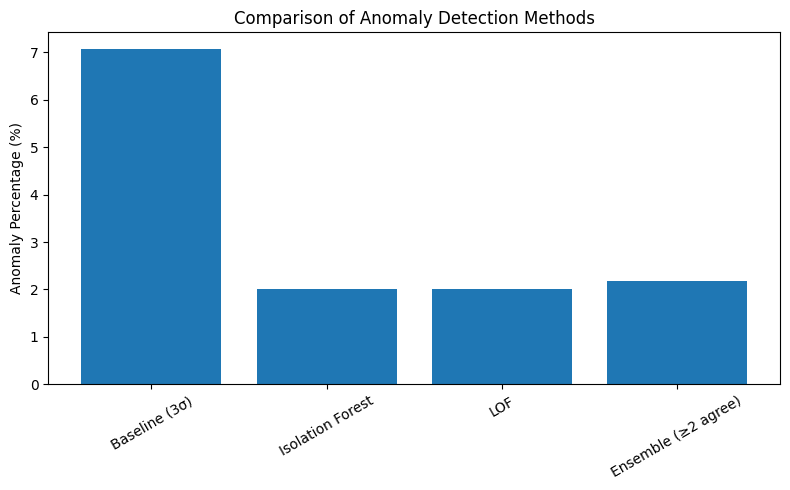

In [9]:
# =========================
# Cell 9 — Anomaly Rate Comparison Plot
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary["Method"], summary["Anomaly_%"])
plt.ylabel("Anomaly Percentage (%)")
plt.title("Comparison of Anomaly Detection Methods")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

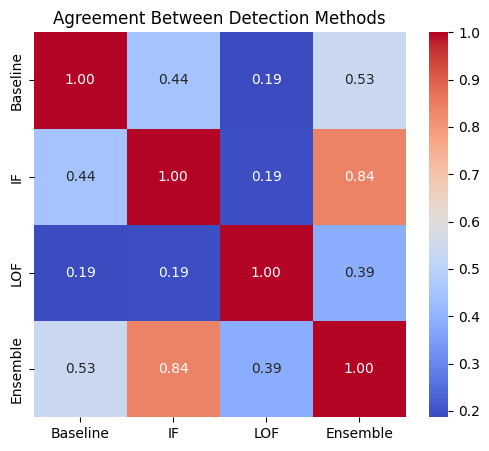

In [10]:
# =========================
# Cell 10 — Agreement Matrix
# =========================

import seaborn as sns

agreement_matrix = pd.DataFrame({
    "Baseline": comparison_df["Baseline_Anomaly"],
    "IF": comparison_df["IF_Anomaly"],
    "LOF": comparison_df["LOF_Anomaly"],
    "Ensemble": comparison_df["Ensemble_Anomaly"]
})

corr = agreement_matrix.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Agreement Between Detection Methods")
plt.show()

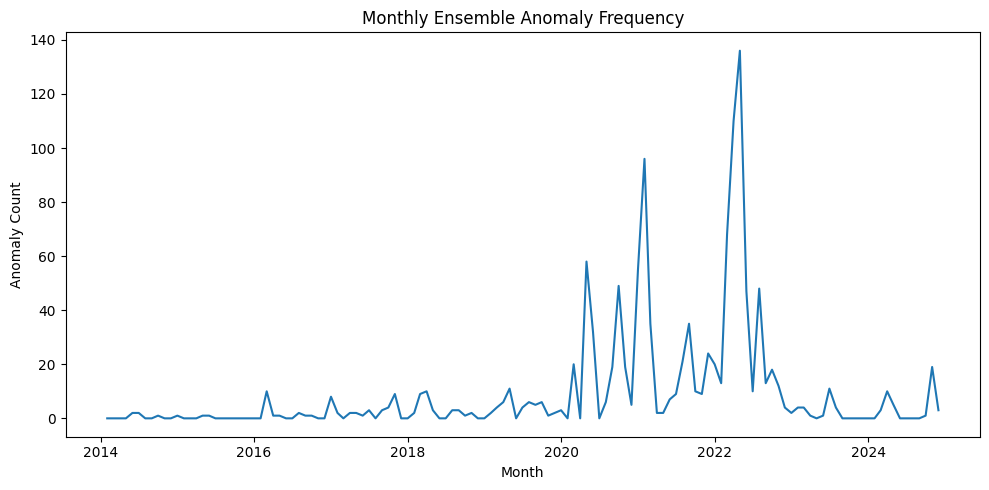

In [11]:
# =========================
# Cell 11 — Monthly Ensemble Anomaly Frequency
# =========================

ensemble_monthly = comparison_df.copy()
ensemble_monthly["Month"] = pd.to_datetime(ensemble_monthly["Date"]).dt.to_period("M")
ensemble_monthly = (
    ensemble_monthly.groupby("Month")["Ensemble_Anomaly"]
    .sum()
    .reset_index()
)

ensemble_monthly["Month"] = ensemble_monthly["Month"].dt.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(ensemble_monthly["Month"],
         ensemble_monthly["Ensemble_Anomaly"])
plt.title("Monthly Ensemble Anomaly Frequency")
plt.ylabel("Anomaly Count")
plt.xlabel("Month")
plt.tight_layout()
plt.show()